# Setup CUDA env

In [ ]:
!python --version
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

Python 3.11.12
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmprm35eak6".


#1. Équation de Schrödinger dépendante du temps (dans sa forme générale)
$$
i\hbar \frac{\partial}{\partial t} \psi(x, t) = -\frac{\hbar^2}{2m} \frac{\partial^2}{\partial x^2} \psi(x, t) + V(x)\psi(x, t)
$$

## A.Que prédit exactement l’équation de Schrödinger ?

L’équation de Schrödinger **ne donne pas directement la position d’une particule**.  
Elle calcule une **fonction d’onde** \( $\psi(x, t)$
), qui est une fonction **complexe**.

Ce qui nous intéresse, c’est le **carré du module** de cette fonction, noté \( $ |\psi(x, t)|^2 $).  
Cela représente la **probabilité** de trouver la particule **à une position \(x\)** à un instant \(t\).

> En résumé :  
> L’équation te dit **où la particule a des chances d’être**, et non **où elle est exactement**.


## B.Que représente la variable `N` dans le code ?

En pratique, tu ne peux pas calculer cette fonction pour **une infinité de positions**.  
Tu dois donc découper l’espace (axe des positions \(x\)) en **un certain nombre de points**.

## C.Discrétisation de l'équation de Schrödinger
Puisque la forme générale d'une onde est  $\psi(x, t)$ = A $\cdot e^{i(kx - \omega t)}$ alors elle est une fonction complexe, on peut l'ecrire comme suit :  
$\psi(x, t)$ = $\Re(\psi(x,t)$) + i . $\Im(\psi(x,t)$).

Pour faire une approximation d'une particle au repos on utilise **un paquet d'ondes gaussien** localisé au centre (x = 0.5) et on annule la partie imaginaire pour que la particle ne soit pas en mouvement.
Ainsi, à t = 0, la fonction d'onde devient :
> $\psi(x, 0) = e^{-100(x - 0.5)^2}$ .


Concernant l'énergie potentiel on va l'annuler V(x) = 0 pour dire qu'aucune force extérieure n'agit sur le particle dans cette zone.


#2. Histoire du code
On imagine une longue ligne qui représente l’espace, découpée en plein de petits morceaux. À chaque point
𝑥, on veut savoir si une particule quantique a une chance d’être là.

Pour cela, on initialise une fonction d’onde
𝜓(𝑥,0), qui est une combinaison de deux paquets d’ondes. \\
- Premier paquet d’ondes :
Il est centré à 𝑥=0.3. \\
Il est bien localisé grâce à une gaussienne et on lui ajoute une oscillation avec cosinus et sinus pour dire qu’il est en mouvement.

- Deuxième paquet d’ondes :
Pareil, mais centré à 𝑥=0.7. \\
Il va dans l’autre sens (sens opposé du premier), donc on inverse le signe dans cos et sin.

Ces deux paquets sont comme deux petites particules quantiques qui vont se croiser plus tard.

 Ensuite, on additionne les deux pour avoir une onde totale, c’est-à-dire l’état global de notre système au départ.

 \\
 Et pour ajouter un peu d’action :
Au centre, entre
𝑥=0.5 et 𝑥=0.51, on met une barrière de potentiel.
C’est comme un mur invisible que les particules vont essayer de traverser ou de réfléchir contre.

# Code CUDA

In [ ]:
%%writefile schrodinger_sim_GPU.cu
#include <iostream>
#include <fstream>
#include <cmath>
#include <chrono>

#define N 1000000      // number of spatial points
#define NSTEPS 1000    // number of time steps
#define DX 0.000001f   // smaller spacing to cover wider range
#define DT 0.0001f
#define PI 3.14159265358979323846
#define HBAR 1.0f
#define MASS 1.0f

__global__ void evolve_gpu(float* real, float* imag, float* V, float dx, float dt) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if (i > 0 && i < N - 1) {
        float r = real[i];
        float im = imag[i];

        float laplacian_r = real[i-1] - 2*r + real[i+1];
        float laplacian_im = imag[i-1] - 2*im + imag[i+1];

        real[i] = r - dt * (-(HBAR*HBAR)/(2*MASS) * laplacian_im / (dx*dx) + V[i]*im);
        imag[i] = im + dt * (-(HBAR*HBAR)/(2*MASS) * laplacian_r / (dx*dx) + V[i]*r);
    }
}

void initialize_wave(float* real, float* imag, float* V) {
    for (int i = 0; i < N; i++) {
        float x = i * DX;

        float packet1_real = expf(-500.0f * (x - 0.3f)*(x - 0.3f)) * cosf(100.0f * x);
        float packet1_imag = expf(-500.0f * (x - 0.3f)*(x - 0.3f)) * sinf(100.0f * x);

        float packet2_real = expf(-500.0f * (x - 0.7f)*(x - 0.7f)) * cosf(-100.0f * x);
        float packet2_imag = expf(-500.0f * (x - 0.7f)*(x - 0.7f)) * sinf(-100.0f * x);

        real[i] = packet1_real + packet2_real;
        imag[i] = packet1_imag + packet2_imag;
        V[i] = 0.0f;

        if (x > 0.5f && x < 0.51f) V[i] = 1000.0f;  // Potential barrier
    }
}

void save_data(float* real, float* imag) {
    std::ofstream file("wave_output_gpu.txt");
    for (int i = 0; i < N; i += 1) {
      // calculates the probability density for each point |psi(x,t)|^2 = real^2 + imag^2
        float prob = real[i]*real[i] + imag[i]*imag[i];
        file << prob << "\n";
    }
    file.close();
}

int main() {
    float *real_cpu = new float[N];
    float *imag_cpu = new float[N];
    float *V_cpu = new float[N];

    initialize_wave(real_cpu, imag_cpu, V_cpu);

    float *real_gpu, *imag_gpu, *V_gpu;
    cudaMalloc(&real_gpu, N * sizeof(float));
    cudaMalloc(&imag_gpu, N * sizeof(float));
    cudaMalloc(&V_gpu, N * sizeof(float));

    cudaMemcpy(real_gpu, real_cpu, N * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(imag_gpu, imag_cpu, N * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(V_gpu, V_cpu, N * sizeof(float), cudaMemcpyHostToDevice);

    dim3 blockSize(256);
    dim3 gridSize((N + blockSize.x - 1) / blockSize.x);

    auto start = std::chrono::high_resolution_clock::now();

    for (int t = 0; t < NSTEPS; t++) {
        evolve_gpu<<<gridSize, blockSize>>>(real_gpu, imag_gpu, V_gpu, DX, DT);
    }

    cudaDeviceSynchronize();

    auto end = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double> duration = end - start;
    std::cout << "GPU time: " << duration.count() << " seconds\n";

    cudaMemcpy(real_cpu, real_gpu, N * sizeof(float), cudaMemcpyDeviceToHost);
    cudaMemcpy(imag_cpu, imag_gpu, N * sizeof(float), cudaMemcpyDeviceToHost);

    save_data(real_cpu, imag_cpu);

    delete[] real_cpu;
    delete[] imag_cpu;
    delete[] V_cpu;
    cudaFree(real_gpu);
    cudaFree(imag_gpu);
    cudaFree(V_gpu);

    return 0;
}


Writing schrodinger_sim_GPU.cu


# Exec code CUDA

In [ ]:
!nvcc schrodinger_sim_GPU.cu -o schrodinger_sim_GPU
!./schrodinger_sim_GPU

GPU time: 0.0459061 seconds


# Code CPU avec C++

In [ ]:
%%writefile schrodinger_sim_CPU.cpp
#include <iostream>
#include <fstream>
#include <cmath>
#include <chrono>
#include <cstdlib> // for std::isnan

#define N 1000000        // Number of points
#define NSTEPS 1000      // Number of steps
#define DX 0.0000001f     // Grid spacing
#define DT 0.000000000000001f      // Time step size
#define HBAR 1.0f
#define MASS 1.0f

void initialize_wave(float* real, float* imag, float* V) {
    for (int i = 0; i < N; i++) {
        float x = i * DX;

        float packet1_real = expf(-500.0f * (x - 0.3f)*(x - 0.3f)) * cosf(100.0f * x);
        float packet1_imag = expf(-500.0f * (x - 0.3f)*(x - 0.3f)) * sinf(100.0f * x);

        float packet2_real = expf(-500.0f * (x - 0.7f)*(x - 0.7f)) * cosf(-100.0f * x);
        float packet2_imag = expf(-500.0f * (x - 0.7f)*(x - 0.7f)) * sinf(-100.0f * x);

        real[i] = packet1_real + packet2_real;
        imag[i] = packet1_imag + packet2_imag;
        V[i] = 0.0f;

        if (x > 0.5f && x < 0.51f) V[i] = 1000.0f;  // Potential barrier
    }
}

void evolve_cpu(float* real, float* imag, float* V, float dx, float dt) {
    float* new_real = new float[N];
    float* new_imag = new float[N];

    for (int t = 0; t < NSTEPS; t++) {
        for (int i = 1; i < N - 1; i++) {  // Avoid boundaries
            float r = real[i];
            float im = imag[i];

            float laplacian_r = real[i-1] - 2*r + real[i+1];
            float laplacian_im = imag[i-1] - 2*im + imag[i+1];

            new_real[i] = r - dt * (-(HBAR*HBAR)/(2*MASS) * laplacian_im / (dx*dx) + V[i]*im);
            new_imag[i] = im + dt * (-(HBAR*HBAR)/(2*MASS) * laplacian_r / (dx*dx) + V[i]*r);
        }


        // Swap
        std::swap(real, new_real);
        std::swap(imag, new_imag);
    }

    delete[] new_real;
    delete[] new_imag;
}

void save_data(float* real, float* imag) {
    std::ofstream file("wave_output_cpu.txt");
    for (int i = 0; i < N; i++) {
        float prob = real[i]*real[i] + imag[i]*imag[i];
        file << prob << "\n";
    }
    file.close();
}

int main() {
    float* real = new float[N];
    float* imag = new float[N];
    float* V = new float[N];

    initialize_wave(real, imag, V);

    auto start = std::chrono::high_resolution_clock::now();

    evolve_cpu(real, imag, V, DX, DT);

    auto end = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double> duration = end - start;
    std::cout << "CPU time: " << duration.count() << " seconds\n";

    save_data(real, imag);

    delete[] real;
    delete[] imag;
    delete[] V;

    return 0;
}



Writing schrodinger_sim_CPU.cpp


# Exec code CPU

In [ ]:
!g++ -O2 schrodinger_sim_CPU.cpp -o sim_cpu
!./sim_cpu


CPU time: 9.40059 seconds


# Visualisation Resultat avec CUDA

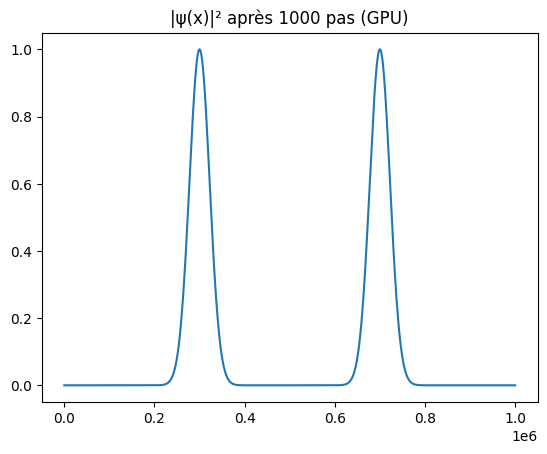

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
data = np.loadtxt("wave_output_gpu.txt")
plt.plot(data)
plt.title("|ψ(x)|² après 1000 pas (GPU)")
plt.show()